In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/drive')

df = pd.read_csv('/drive/MyDrive/Customer Churn Prediction/customer_churn_dataset-testing-master.csv')

Mounted at /drive


In [22]:
df = pd.read_csv('/drive/MyDrive/Customer Churn Prediction/customer_churn_dataset-training-master.csv')

In [23]:
type(df)

pandas.core.frame.DataFrame

In [24]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [26]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [27]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
1.0,0.567107
0.0,0.432893


In [29]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [30]:
df.isnull()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,False,False,False,False,False,False,False,False,False,False,False,False
440829,False,False,False,False,False,False,False,False,False,False,False,False
440830,False,False,False,False,False,False,False,False,False,False,False,False
440831,False,False,False,False,False,False,False,False,False,False,False,False


In [34]:
df = df.dropna(how="all")
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [35]:
df.groupby("Churn")["Last Interaction"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,13.008804,8.291378,1.0,6.0,12.0,19.0,30.0
1.0,249999.0,15.604546,8.654930,1.0,8.0,16.0,23.0,30.0


In [36]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[["Gender", "Subscription Type", "Contract Length"]])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(["Gender", "Subscription Type", "Contract Length"]))
df = pd.concat([df, encoded_df], axis=1)
df.drop(["Gender", "Subscription Type", "Contract Length"], axis=1, inplace=True)

df.corr()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
CustomerID,1.000000,-0.181977,0.044129,0.038455,-0.482894,-0.262029,0.359289,-0.125356,-0.839365,0.146921,0.007948,0.006843,-0.363187,0.148528
Age,-0.181977,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394,-0.032156,-0.004417,-0.000723,0.088842,-0.035410
Tenure,0.044129,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919,0.008021,0.000880,0.001707,-0.021126,0.008744
Usage Frequency,0.038455,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101,0.006356,0.000306,-0.000332,-0.019601,0.008227
Support Calls,-0.482894,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267,-0.092198,-0.006902,-0.004557,0.229053,-0.093229
Payment Delay,-0.262029,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129,-0.051540,-0.002576,-0.001379,0.127788,-0.053903
Total Spend,0.359289,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355,0.067766,0.003699,0.004961,-0.172036,0.069820
Last Interaction,-0.125356,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616,-0.028751,-0.003476,0.001102,0.060606,-0.026275
Churn,-0.839365,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000,-0.175315,-0.011035,-0.009239,0.433308,-0.176172
Gender_Male,0.146921,-0.032156,0.008021,0.006356,-0.092198,-0.051540,0.067766,-0.028751,-0.175315,1.000000,0.003189,-0.002469,-0.067611,0.025533


In [37]:
corr = df.corr(numeric_only=True)
corr["Churn"].abs().sort_values(ascending=False)

,Churn
Churn,1.000000
CustomerID,0.839365
Support Calls,0.574267
Contract Length_Monthly,0.433308
Total Spend,0.429355
Payment Delay,0.312129
Age,0.218394
Contract Length_Quarterly,0.176172
Gender_Male,0.175315
Last Interaction,0.149616


In [38]:
import numpy as np

corr = df.corr(numeric_only=True)

mask = corr.where(~np.tril(np.ones(corr.shape)).astype(bool))

strong_corr = (
    mask.stack()
        .sort_values(key=abs, ascending=False)
)

strong_corr.head(20)

CustomerID                 Churn                        -0.839365
Support Calls              Churn                         0.574267
Subscription Type_Premium  Subscription Type_Standard   -0.510065
CustomerID                 Support Calls                -0.482894
Churn                      Contract Length_Monthly       0.433308
Total Spend                Churn                        -0.429355
Contract Length_Monthly    Contract Length_Quarterly    -0.405549
CustomerID                 Contract Length_Monthly      -0.363187
                           Total Spend                   0.359289
Payment Delay              Churn                         0.312129
CustomerID                 Payment Delay                -0.262029
Support Calls              Contract Length_Monthly       0.229053
                           Total Spend                  -0.221594
Age                        Churn                         0.218394
CustomerID                 Age                          -0.181977
Churn                      Contract Length_Quarterly    -0.176172
                           Gender_Male                  -0.175315
Total Spend                Contract Length_Monthly      -0.172036
Support Calls              Payment Delay                 0.162889
Age                        Support Calls                 0.158451
dtype: float64

In [39]:
df["Churn"].value_counts(normalize=True)

corr = (
    df.corr(numeric_only=True)["Churn"]
      .drop("Churn")
      .abs()
      .sort_values(ascending=False)
)

corr.head(10)

,Churn
CustomerID,0.839365
Support Calls,0.574267
Contract Length_Monthly,0.433308
Total Spend,0.429355
Payment Delay,0.312129
Age,0.218394
Contract Length_Quarterly,0.176172
Gender_Male,0.175315
Last Interaction,0.149616
Tenure,0.051919


<Axes: xlabel='CustomerID', ylabel='Density'>

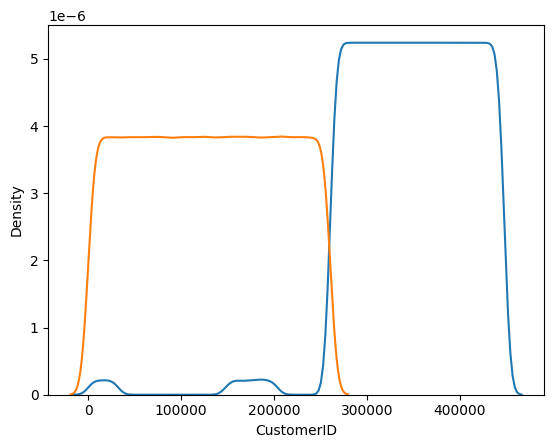

In [40]:
import seaborn as sns

sns.kdeplot(df[df["Churn"]==0]["CustomerID"])
sns.kdeplot(df[df["Churn"]==1]["CustomerID"])

<Axes: xlabel='Payment Delay', ylabel='Density'>

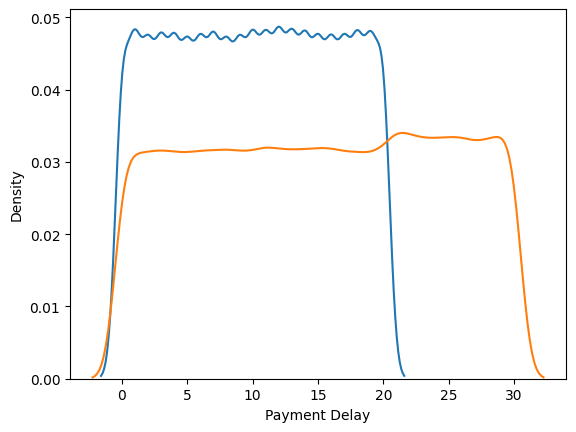

In [41]:
import seaborn as sns

sns.kdeplot(df[df["Churn"]==0]["Payment Delay"])
sns.kdeplot(df[df["Churn"]==1]["Payment Delay"])

<Axes: xlabel='Tenure', ylabel='Density'>

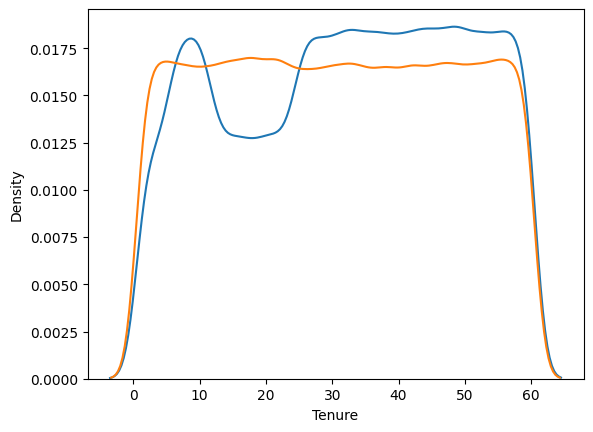

In [42]:
import seaborn as sns

sns.kdeplot(df[df["Churn"]==0]["Tenure"])
sns.kdeplot(df[df["Churn"]==1]["Tenure"])


In [43]:
df.drop(['CustomerID'], axis=1, inplace=True)

df["Churn"].value_counts(normalize=True)

corr = (
    df.corr(numeric_only=True)["Churn"]
      .drop("Churn")
      .abs()
      .sort_values(ascending=False)
)

corr.head(10)

,Churn
Support Calls,0.574267
Contract Length_Monthly,0.433308
Total Spend,0.429355
Payment Delay,0.312129
Age,0.218394
Contract Length_Quarterly,0.176172
Gender_Male,0.175315
Last Interaction,0.149616
Tenure,0.051919
Usage Frequency,0.046101


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

df.dropna(inplace=True) # Ensure no NaNs in the dataframe before splitting
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier()
model.fit(X_train, y_train)

res = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, model.predict(X_test))],
    "precision_score": [precision_score(y_test, model.predict(X_test))],
    "recall_score": [recall_score(y_test, model.predict(X_test))],
    "f1_score": [f1_score(y_test, model.predict(X_test))]
})

res.style.set_caption("Result with RandomForest Method")

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(
    importance.sort_values(
        "importance",
        ascending=False
    )
)

                       feature  importance
3                Support Calls    0.307821
5                  Total Spend    0.222248
0                          Age    0.152812
4                Payment Delay    0.132171
10     Contract Length_Monthly    0.128496
6             Last Interaction    0.015495
1                       Tenure    0.015147
7                  Gender_Male    0.009296
2              Usage Frequency    0.009235
11   Contract Length_Quarterly    0.005287
9   Subscription Type_Standard    0.001050
8    Subscription Type_Premium    0.000941


In [46]:
display(res)

,Accuracy,precision_score,recall_score,f1_score
0,0.988295,0.999817,0.979582,0.989596


  0%|          | 0/50 [00:00<?, ?it/s]

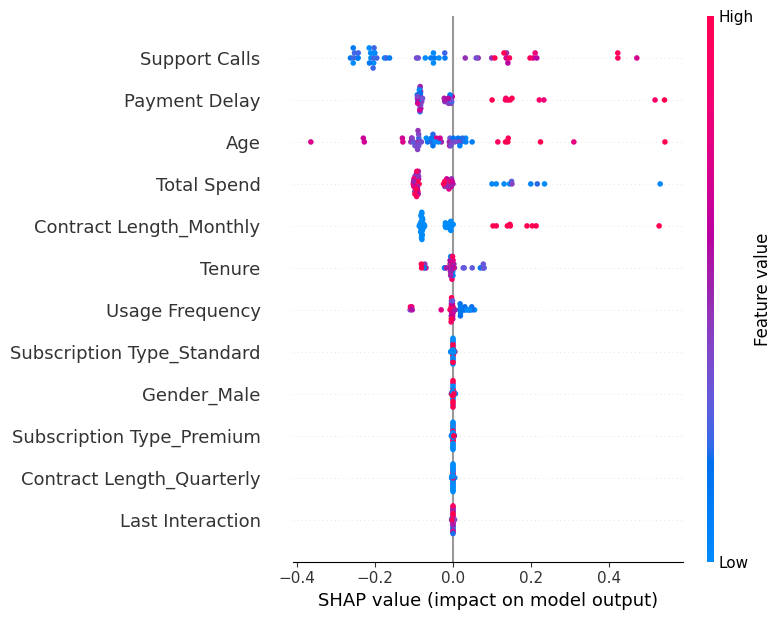

In [47]:
import shap

explainer = shap.KernelExplainer(model.predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(shap_values, X_test[:50])